## **Import & Setup**

In [ ]:
import sys, json, re
import pandas as pd
import json
from tqdm import tqdm
sys.path.append('../src')
from evaluation import evaluate, print_results
from pipeline import make_itemcf_backend
from llm import call_llm
from plots import plot_metric_grid

## **Load the Data**

In [2]:
DATA = '../data'
train_matrix = pd.read_parquet(f'{DATA}/train_matrix.parquet')
full_matrix  = pd.read_parquet(f'{DATA}/interaction_matrix_raw.parquet')
test_df      = pd.read_parquet(f'{DATA}/test_pairs.parquet')
feats        = pd.read_parquet(f'{DATA}/neighborhood_features.parquet')

In [ ]:
head = set(train_matrix.sum(axis=0).sort_values(ascending=False).head(10).index)
itemcf_backend = make_itemcf_backend(train_matrix)

['nace', 'neighborhood', 'original_count']


In [18]:
NACE_COL = 'nace' 
NACE_DATA_PATH = 'C:\\Users\\Giorgos\\Desktop\\HMMY\\10ο Εξάμηνο\\Διπλωματική\\02. General Data - Directories\\3. NACE Data'

df_naces  = pd.read_csv(NACE_DATA_PATH + '\\unique_naces.csv')     # adjust path
nace_dict = dict(zip(df_naces['NACE Code'].astype(float), df_naces['Class Description']))

In [19]:
NEIGHBORHOODS = list(train_matrix.columns)

def feat_line(n, r):
    return (
        f"- {n}: {r['distance_to_volos_center_km']:.1f}km from centre, "
        f"{r['distance_to_volos_port_km']:.1f}km from coast, "
        f"{r['dist_to_university_km']:.1f}km from university, "
        f"area {r['Neighborhood_Area_km2']:.1f}km2"
    )

NEIGHBORHOOD_BLOCK = "\n".join(feat_line(n, feats.loc[n]) for n in NEIGHBORHOODS)
print(NEIGHBORHOOD_BLOCK[:300])

- Agia Kyriaki: 1.9km from centre, 2.9km from coast, 1.0km from university, area 1.1km2
- Agia Paraskeui: 1.7km from centre, 2.7km from coast, 2.0km from university, area 0.9km2
- Agioi Anargiroi: 2.3km from centre, 2.0km from coast, 0.9km from university, area 0.8km2
- Agios Apostolos o Neos: 7.5km


## **Pure LLM Ranker**

In [20]:
def llm_rank(nace):
    nace_desc = nace_dict.get(float(nace), str(nace))
    
    prompt = f"""An entrepreneur wants to open a business of type: "{nace_desc}".

        Here are the neighbourhoods of Volos with their characteristics:
        {NEIGHBORHOOD_BLOCK}

        Using these characteristics and your knowledge of where such a business tends to succeed, rank the 10 MOST suitable neighbourhoods, best first.
        Output ONLY a JSON array of neighbourhood names, e.g. ["Name1","Name2",...]. No other text.
    """
    raw = call_llm(prompt)
    m = re.search(r'\[.*\]', raw, re.DOTALL)
    if not m:
        return []
    try:
        names = json.loads(m.group(0))
    except json.JSONDecodeError:
        return []
    return [n for n in names if n in set(NEIGHBORHOODS)]   # drop hallucinated names

In [ ]:
# sanity check for one nace
sample = test_df.iloc[0][NACE_COL]
print(sample, '->', nace_dict.get(float(sample)))
print(llm_rank(sample))

1.13 -> Growing of vegetables and melons, roots and tubers
['Agios Nikolaos', 'Agia Kyriaki', 'Agios Georgios', 'Nea Ionia', 'Portaria', 'Hiliadou', 'Iolkos', 'Karagats', 'Makrinitsa', 'Ano Lehonia']


## **Inference on the Test Set**

In [23]:
test_naces = test_df[NACE_COL].unique()
llm_rankings = {n: llm_rank(n) for n in tqdm(test_naces)}

100%|██████████| 244/244 [54:40<00:00, 13.44s/it] 


In [ ]:
with open('../results/llm_rankings.json', 'w', encoding='utf-8') as f:
    json.dump({str(k): v for k, v in llm_rankings.items()}, f, ensure_ascii=False, indent=2)

## **Evaluation: LLM Vs CF**

In [25]:
def llm_baseline(nace):
    ranking = llm_rankings.get(nace, [])
    scores = pd.Series(0.0, index=NEIGHBORHOODS)
    for pos, name in enumerate(ranking):
        scores[name] = len(ranking) - pos          # rank 1 -> highest score
    return scores

In [26]:
summary_llm, _ = evaluate(llm_baseline, test_df, full_matrix, head_neighborhoods=head)
print_results('Pure LLM (features + world knowledge, no interaction data)', summary_llm)

Pure LLM (features + world knowledge, no interaction data) — full test set:
  HR@1: 0.1189
  NDCG@1: 0.1189
  HR@3: 0.2172
  NDCG@3: 0.1739
  HR@5: 0.2787
  NDCG@5: 0.1999
  HR@10: 0.3975
  NDCG@10: 0.2380
  (n = 244)

Pure LLM (features + world knowledge, no interaction data) — long-tail subset:
  HR@1: 0.0500
  NDCG@1: 0.0500
  HR@3: 0.2000
  NDCG@3: 0.1359
  HR@5: 0.2167
  NDCG@5: 0.1431
  HR@10: 0.3333
  NDCG@10: 0.1813
  (n = 60)



In [27]:
summary_cf, _ = evaluate(itemcf_backend, test_df, full_matrix, head_neighborhoods=head)
print_results('ItemCF (interaction data)', summary_cf)

ItemCF (interaction data) — full test set:
  HR@1: 0.2582
  NDCG@1: 0.2582
  HR@3: 0.4467
  NDCG@3: 0.3686
  HR@5: 0.5492
  NDCG@5: 0.4109
  HR@10: 0.7582
  NDCG@10: 0.4783
  (n = 244)

ItemCF (interaction data) — long-tail subset:
  HR@1: 0.0833
  NDCG@1: 0.0833
  HR@3: 0.2667
  NDCG@3: 0.1925
  HR@5: 0.3833
  NDCG@5: 0.2398
  HR@10: 0.5833
  NDCG@10: 0.3022
  (n = 60)



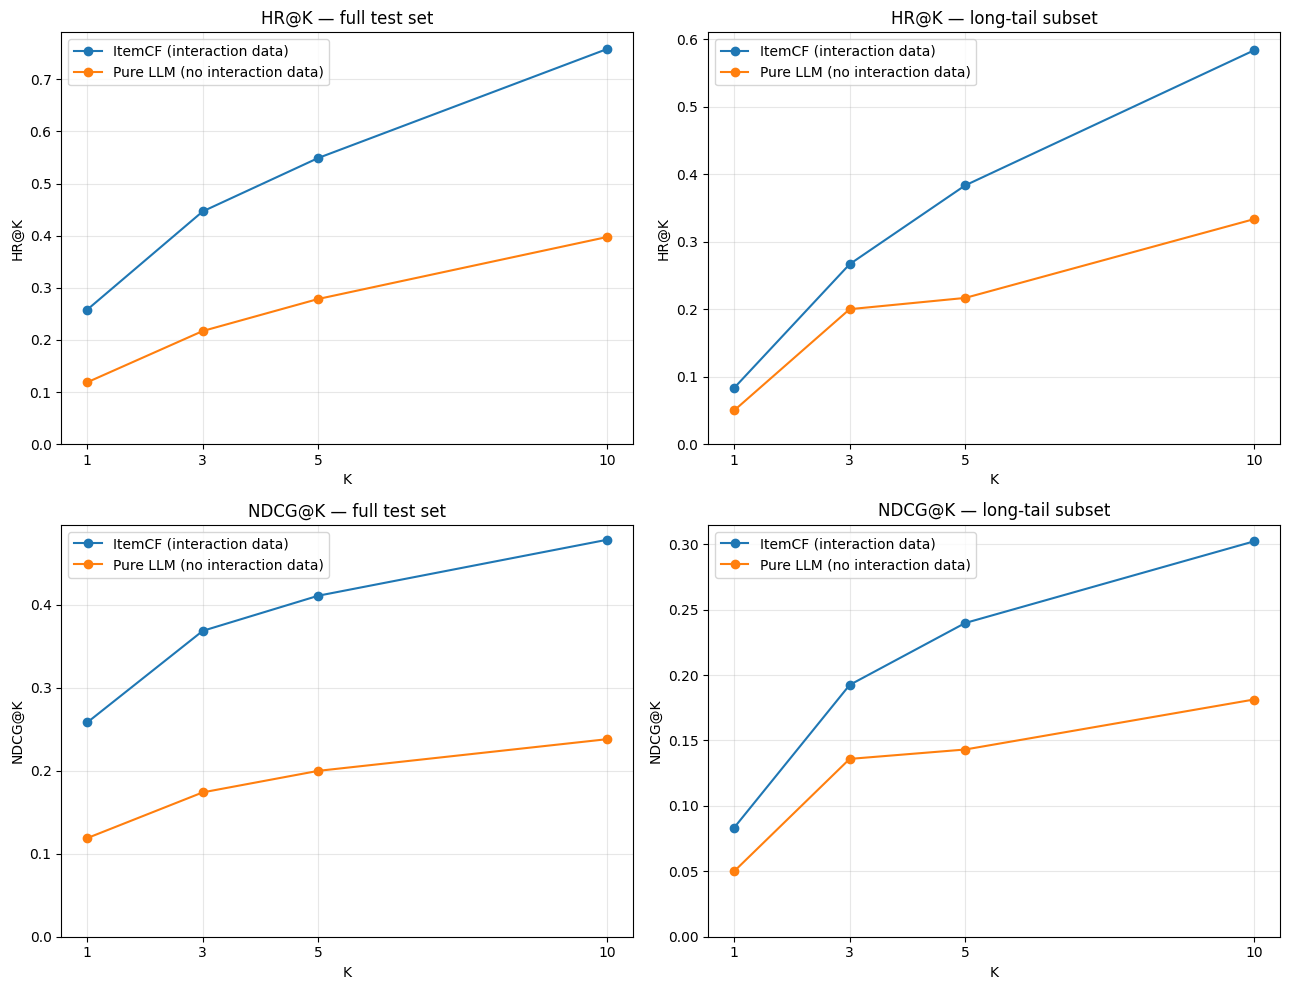

In [29]:
summaries = {
    'ItemCF (interaction data)':       summary_cf,
    'Pure LLM (no interaction data)':  summary_llm,
}
plot_metric_grid(summaries, path='../results/llm_vs_cf.png')

This actually proves that CF outperforms pure-LLMs in recommendation tasks, which is expected, therefore supporting the need for a hybrid model!